In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Load the data

In [18]:
df = pd.read_csv('data/train.csv')

In [19]:
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


# Load the data

In [20]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


# Handle missing age

In [21]:
# Extract Title
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

# Check the counts
print(df['Title'].value_counts())

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Major         2
Mlle          2
Col           2
Don           1
Mme           1
Ms            1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64


In [22]:
# Calculate the average age for each title
title_means = df.groupby('Title')['Age'].transform('mean')
print(f'title means :{title_means}')

# Fill missing Age values
df['Age'] = df['Age'].fillna(title_means)

# Verify
print(f"Missing ages: {df['Age'].isnull().sum()}")

title means :0      32.368090
1      35.898148
2      21.773973
3      35.898148
4      32.368090
         ...    
886    43.166667
887    21.773973
888    21.773973
889    32.368090
890    32.368090
Name: Age, Length: 891, dtype: float64
Missing ages: 0


# Drop coulmns

In [23]:
df.drop(columns=['Cabin'], inplace=True)
df.drop(columns=['Ticket'], inplace=True)
print(df.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Fare', 'Embarked', 'Title'],
      dtype='str')


In [24]:
# Calculate Family size
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# C1 if alone, 0 if with family)
df['isAlone'] = 0 
df.loc[df['FamilySize'] == 1, 'isAlone'] = 1

# Check the first few rows
print(df[['isAlone', 'FamilySize', 'Survived']].head())

   isAlone  FamilySize  Survived
0        0           2         0
1        0           2         1
2        1           1         1
3        0           2         1
4        1           1         0


In [25]:
#AgeGroup binning
bins=[0,12,19,35,55,100]
labels = ['Child', 'Teen', 'YoungAdult', 'Adult', 'Senior']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, include_lowest=True)


In [26]:
#FareGroup binning
bins=[0,7.91,14.45,31,513]
labels = ['Low', 'Medium', 'High', 'VeryHigh']
df['FareGroup']=pd.cut(df['Fare'],bins=bins,labels=labels,include_lowest=True)

# Model

In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

 # Map Sex to numbers
df['Sex'] = df['Sex'].replace(['male', 'female'], [0, 1])
features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "FamilySize"]


X = df[features]
y = df["Survived"]

# Split the data 
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
#Initialize the model
model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

model.fit(X_train, y_train)

# Check the Score
Accuracy = model.score(X_val, y_val)
print(f"Model Accuracy on Validation Set: {Accuracy:.2%}")

from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)
print(f"Average Accuracy: {scores.mean():.2%}")

Model Accuracy on Validation Set: 83.80%
Average Accuracy: 82.27%


In [29]:
# Evaluate the model

from sklearn.metrics import confusion_matrix, classification_report

y_pred = model.predict(X_val)

print("Accuracy:", model.score(X_val, y_val))
cm = confusion_matrix(y_val, y_pred, labels=[0, 1])
print("Confusion Matrix (rows: actual, columns: predicted)")
print(cm)
report = classification_report(y_val, y_pred)
print(report)

Accuracy: 0.8379888268156425
Confusion Matrix (rows: actual, columns: predicted)
[[95 10]
 [19 55]]
              precision    recall  f1-score   support

           0       0.83      0.90      0.87       105
           1       0.85      0.74      0.79        74

    accuracy                           0.84       179
   macro avg       0.84      0.82      0.83       179
weighted avg       0.84      0.84      0.84       179



To evaluate the model across all possible thresholds, we use ROC-AUC (Area under the ROC Curve). ROC-AUC asks: “How well does the model rank survivors higher than non-survivors?”

In [30]:
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

y_proba = model.predict_proba(X_val)[:, 1]
roc_auc = roc_auc_score(y_val, y_proba)
print("ROC-AUC:", roc_auc)

ROC-AUC: 0.8963320463320463


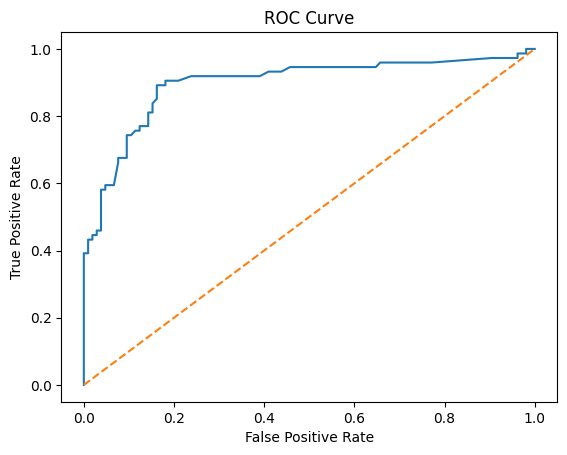

In [32]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_val, y_proba)

plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [31]:
import joblib
import os

# Pointing to the folder
model_dir = 'ml_models'

# Save the files
joblib.dump(model, os.path.join(model_dir, 'titanic_model.pkl'))
joblib.dump(list(X.columns), os.path.join(model_dir, 'model_columns.pkl'))

print("Files saved successfully to the root ml_models folder!")

Files saved successfully to the root ml_models folder!
